In [1]:
import requests
import json
import os
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import shap

In [2]:
working_dir='/Users/amittiwari/Desktop/Course Document/Project/Python/Main'
os.chdir(working_dir)

In [3]:
df_foodgrains = pd.read_csv('df_foodgrains_geoposition.csv')

In [4]:
MIN_REQUIRED_YEARS = 13

# Select all columns from the 3rd column onward (index 2)
yield_columns = df_foodgrains.columns[2:]

# Count non-null values in each row for these columns
df_foodgrains['Non_Null_Yield_Count'] = df_foodgrains[yield_columns].notnull().sum(axis=1)

# Keep only rows with at least MIN_REQUIRED_YEARS non-null values
df_cleaned = df_foodgrains[df_foodgrains['Non_Null_Yield_Count'] >= MIN_REQUIRED_YEARS].copy()

# Drop the helper column
df_cleaned_foodgrain = df_cleaned.drop(columns=['Non_Null_Yield_Count'])

In [5]:
df_pre = df_cleaned_foodgrain[yield_columns].ffill(axis=1)

df_post = df_cleaned_foodgrain[yield_columns].bfill(axis=1)

df_mean_values = (df_pre + df_post) / 2

df_cleaned_foodgrain[yield_columns] = df_cleaned_foodgrain[yield_columns].fillna(df_mean_values)

df_cleaned_foodgrain[yield_columns] = df_cleaned_foodgrain[yield_columns].ffill(axis=1).bfill(axis=1)

In [6]:
df_climate_soil = pd.read_csv("Complete_climate_soil_combined.csv")
df_climate_soil.dropna(inplace=True)

In [7]:
id_vars = ['State', 'District']
value_vars = [col for col in df_cleaned_foodgrain.columns if col not in id_vars]

df_yield_long = df_cleaned_foodgrain.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Year',          
    value_name='Yield_Hectare' 
)

df_final = pd.merge(
    df_climate_soil,
    df_yield_long,
    on=['State', 'District', 'Year'],
    how='inner' 
)

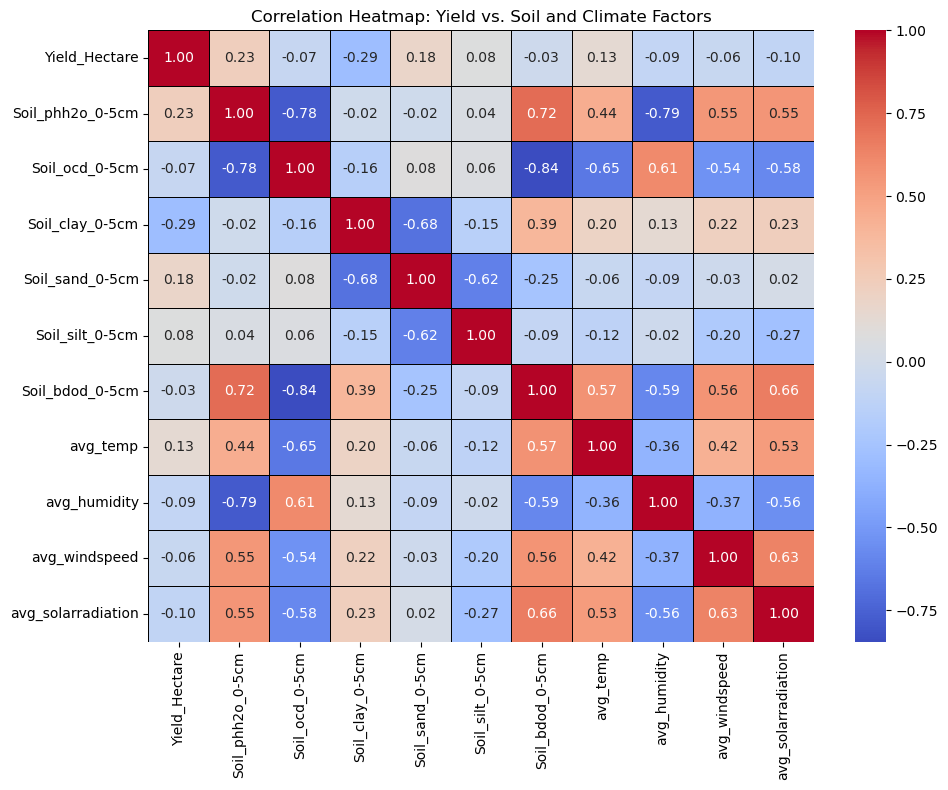

In [8]:
numerical_cols = [
    'Yield_Hectare', 'Soil_phh2o_0-5cm', 'Soil_ocd_0-5cm', 'Soil_clay_0-5cm', 
    'Soil_sand_0-5cm', 'Soil_silt_0-5cm', 'Soil_bdod_0-5cm', 
    'avg_temp', 'avg_humidity', 'avg_windspeed', 'avg_solarradiation'
]
df_corr = df_final[numerical_cols]

# 2. Calculate the correlation matrix
correlation_matrix = df_corr.corr()

# 3. Generate the Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    linewidths=.5,
    linecolor='black'
)
plt.title('Correlation Heatmap: Yield vs. Soil and Climate Factors')
plt.tight_layout()

In [9]:
numerical_cols = [
    'Soil_phh2o_0-5cm', 'Soil_ocd_0-5cm', 'Soil_clay_0-5cm', 
    'Soil_sand_0-5cm', 'Soil_silt_0-5cm', 'Soil_bdod_0-5cm',
    'avg_temp', 'avg_humidity', 'avg_windspeed', 'avg_solarradiation',
    'Yield_Hectare'
]

# Calculate the correlation matrix
correlation_matrix = df_final[numerical_cols].corr()

# Extract and print correlations specifically for Yield_Hectare
yield_corr = correlation_matrix['Yield_Hectare'].sort_values(ascending=False)

print("\n--- Your Correlation Values with Yield_Hectare ---")
print(yield_corr)
print("--------------------------------------------------\n")

# Also print the count of non-null values to confirm data integrity
print(f"Total rows in your file: {len(df_final)}")
print(f"Non-null yield values: {df_final['Yield_Hectare'].count()}")


--- Your Correlation Values with Yield_Hectare ---
Yield_Hectare         1.000000
Soil_phh2o_0-5cm      0.232834
Soil_sand_0-5cm       0.177308
avg_temp              0.130293
Soil_silt_0-5cm       0.077641
Soil_bdod_0-5cm      -0.026910
avg_windspeed        -0.060830
Soil_ocd_0-5cm       -0.071668
avg_humidity         -0.089988
avg_solarradiation   -0.100087
Soil_clay_0-5cm      -0.294703
Name: Yield_Hectare, dtype: float64
--------------------------------------------------

Total rows in your file: 9496
Non-null yield values: 9496


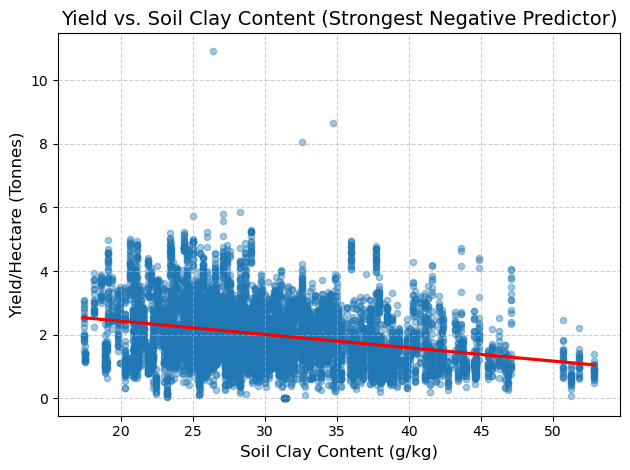

In [10]:
sns.regplot(
    data=df_final,
    x='Soil_clay_0-5cm',
    y='Yield_Hectare',
    scatter_kws={'alpha':0.4, 's': 20},
    line_kws={'color': 'red'}
)

plt.title('Yield vs. Soil Clay Content (Strongest Negative Predictor)', fontsize=14)
plt.xlabel('Soil Clay Content (g/kg)', fontsize=12)
plt.ylabel('Yield/Hectare (Tonnes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


/var/folders/t9/dq9137bj5c5b9m43j7jznhlc0000gn/T/ipykernel_89198/3966610771.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


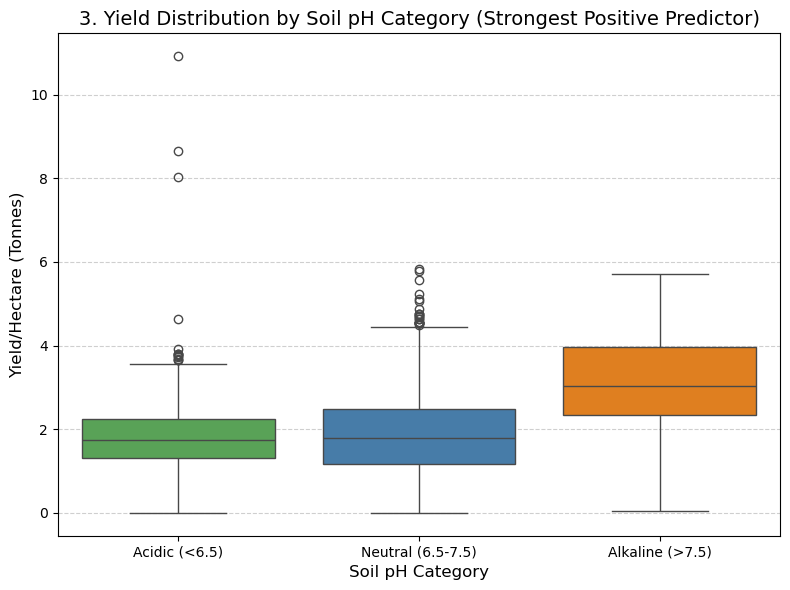

In [11]:
def categorize_ph(ph):
    if ph < 6.5:
        return 'Acidic (<6.5)'
    elif ph <= 7.5:
        return 'Neutral (6.5-7.5)'
    else:
        return 'Alkaline (>7.5)'

df_final['pH_Category'] = df_final['Soil_phh2o_0-5cm'].apply(categorize_ph)

# Set the desired order for the categories
ph_order = ['Acidic (<6.5)', 'Neutral (6.5-7.5)', 'Alkaline (>7.5)']

# --- 2. Generate the Box Plot ---
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_final,
    x='pH_Category',
    y='Yield_Hectare',
    order=ph_order,
    palette=['#4daf4a', '#377eb8', '#ff7f00'] # Custom colors
)

plt.title('3. Yield Distribution by Soil pH Category (Strongest Positive Predictor)', fontsize=14)
plt.xlabel('Soil pH Category', fontsize=12)
plt.ylabel('Yield/Hectare (Tonnes)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

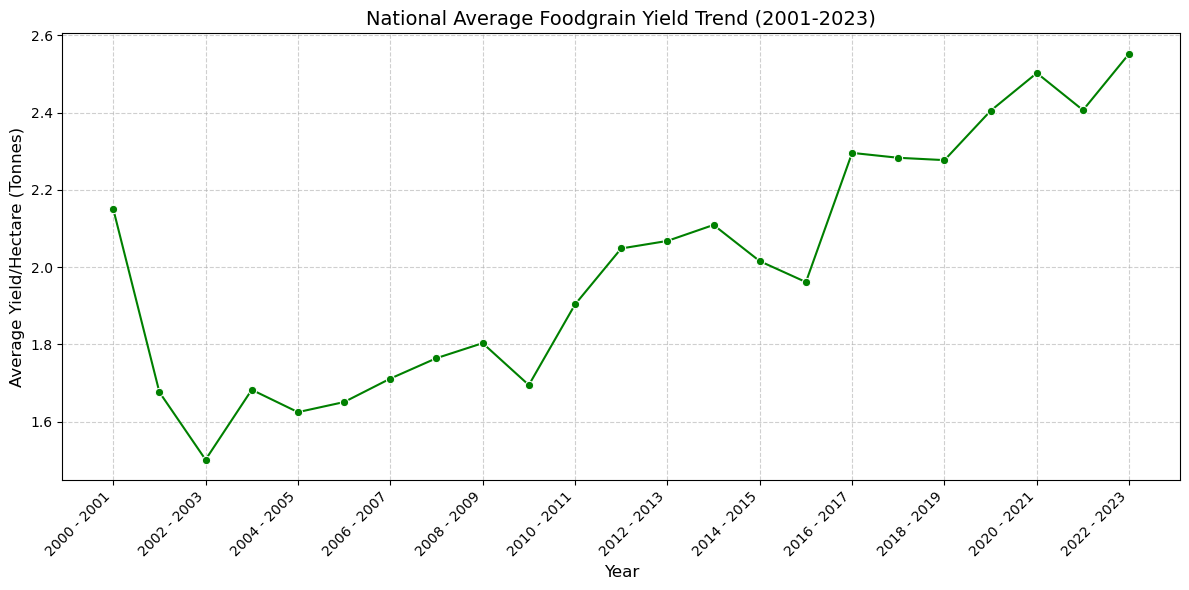

In [12]:
df_trend = df_final.groupby('Year')['Yield_Hectare'].mean().reset_index()

# 2. Sort years for correct plotting order
# We convert '2000 - 2001' format to a sortable numerical format (e.g., 2000)
df_trend['Start_Year'] = df_trend['Year'].str.split(' - ').str[0].astype(int)
df_trend = df_trend.sort_values('Start_Year').drop(columns=['Start_Year'])

# 3. Create the Time Series Plot
plt.figure(figsize=(12, 6))

sns.lineplot(x='Year', y='Yield_Hectare', data=df_trend, color='green', marker='o')

# Set X-axis ticks to be readable (show every 2nd year)
tick_labels = df_trend['Year'].tolist()
plt.xticks(range(0, len(tick_labels), 2), [tick_labels[i] for i in range(0, len(tick_labels), 2)], rotation=45, ha='right')

plt.title('National Average Foodgrain Yield Trend (2001-2023)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Yield/Hectare (Tonnes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

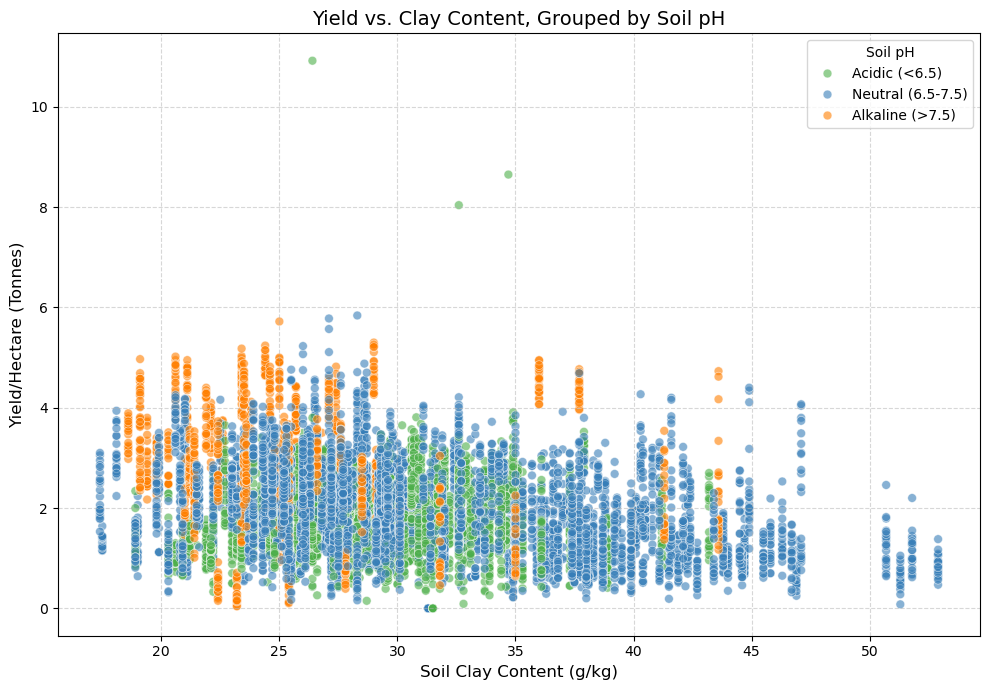

In [13]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_final,
    x='Soil_clay_0-5cm',
    y='Yield_Hectare',
    hue='pH_Category',       # Color points based on pH category
    hue_order=ph_order,
    palette=['#4daf4a', '#377eb8', '#ff7f00'],
    s=40,                    # Point size
    alpha=0.6                # Transparency
)

plt.title('Yield vs. Clay Content, Grouped by Soil pH', fontsize=14)
plt.xlabel('Soil Clay Content (g/kg)', fontsize=12)
plt.ylabel('Yield/Hectare (Tonnes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Soil pH', loc='upper right')
plt.tight_layout()

In [14]:
df_final.drop('pH_Category', axis=1, inplace=True)

In [15]:
df_final['Start_Year'] = df_final['Year'].str.split(' - ').str[0].astype(int)
df_final = df_final.drop(columns=['Year'])

In [16]:
y = df_final['Yield_Hectare']
X = df_final.drop(columns=['Yield_Hectare','State','District','Latitude','Longitude'])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
linear_model_stable = LinearRegression()
linear_model_stable.fit(X_train, y_train)

y_pred_stable = linear_model_stable.predict(X_test)

In [19]:
mse_stable = mean_squared_error(y_test, y_pred_stable)
rmse_stable = np.sqrt(mse_stable)
rmse_stable

np.float64(0.7869997224544449)

In [20]:
r2_stable = r2_score(y_test, y_pred_stable)
r2_stable

0.3238290422855854

In [21]:
coefficients_stable = pd.Series(linear_model_stable.coef_, index=X.columns)
top_5_coefs_stable = coefficients_stable.abs().sort_values(ascending=False).head(5)

print(coefficients_stable.loc[top_5_coefs_stable.index])

Soil_phh2o_0-5cm    0.766523
Soil_bdod_0-5cm    -0.514606
avg_windspeed      -0.248296
Soil_clay_0-5cm    -0.153862
Soil_silt_0-5cm    -0.124418
dtype: float64


In [22]:
rf_model = RandomForestRegressor(
    n_estimators=11, 
    random_state=42,
    n_jobs=-1       
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [23]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
r2_rf

0.8376044527198747

In [24]:
rmse_rf

np.float64(0.38568556161184164)

In [25]:
feature_importances_lag = pd.Series(rf_model.feature_importances_, index=X.columns)
top_5_lag_features = feature_importances_lag.sort_values(ascending=False).head(5)

print(top_5_lag_features)

Soil_phh2o_0-5cm      0.253442
Start_Year            0.127381
Soil_ocd_0-5cm        0.088902
Soil_clay_0-5cm       0.082733
avg_solarradiation    0.080330
dtype: float64


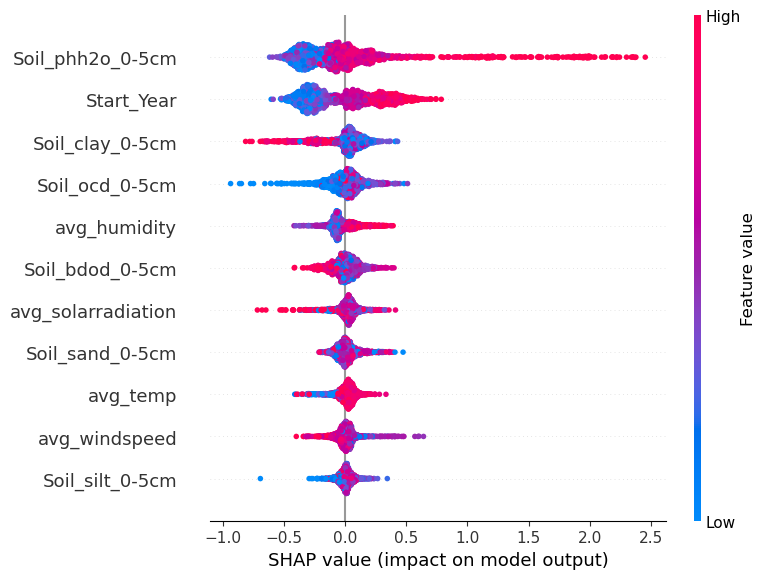

In [26]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

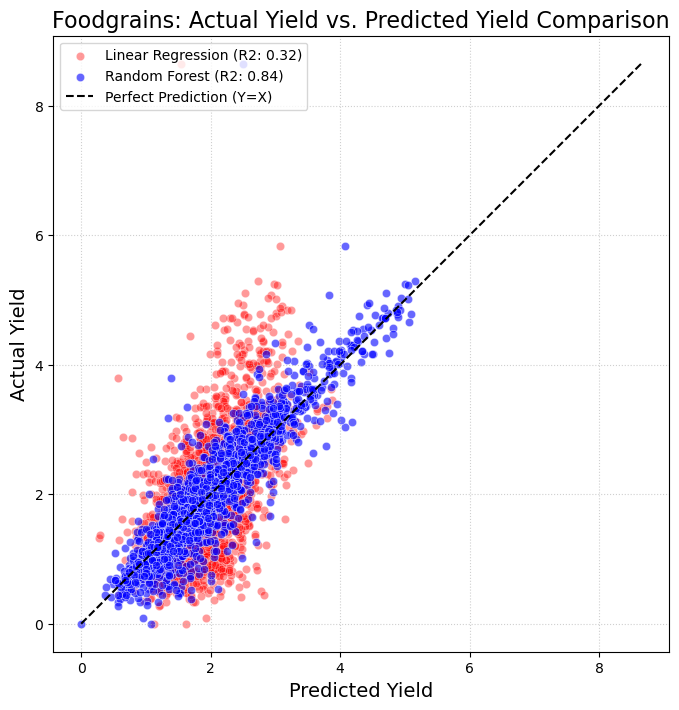

In [27]:
plt.figure(figsize=(10, 8))


sns.scatterplot(
    x=y_pred_stable,
    y=y_test,
    color='red',
    alpha=0.4,
    label=f'Linear Regression (R2: {r2_stable:.2f})'
)


sns.scatterplot(
    x=y_pred_rf,
    y=y_test,
    color='blue',
    alpha=0.6,
    label=f'Random Forest (R2: {r2_rf:.2f})'
)

# 3. Plot the perfect prediction line (Y=X)
max_val = max(y_test.max(), y_pred_rf.max(), y_pred_stable.max())
min_val = min(y_test.min(), y_pred_rf.min(), y_pred_stable.min())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect Prediction (Y=X)')

plt.title('Foodgrains: Actual Yield vs. Predicted Yield Comparison', fontsize=16)
plt.xlabel('Predicted Yield', fontsize=14)
plt.ylabel('Actual Yield', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()